# ML Classification Baseline

**Paper 2: Cross-Code Comparative Analysis - Part 6**

This notebook establishes machine learning baselines for legal text classification:

1. **Code Classification**: Predict which legal code an article belongs to (5-class)
2. **Penalty Type Classification**: Predict penalty type from article text
3. **Feature Comparison**: TF-IDF with different n-gram ranges
4. **Model Comparison**: Logistic Regression, Random Forest, SVM, Naive Bayes

**Goal**: Establish baseline accuracy metrics for legal NLP tasks on Kazakhstan's legal codes.

## 1. Setup and Imports

In [89]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

# NLP
import spacy

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Load spaCy
nlp = spacy.load("ru_core_news_sm")

# Create output directory
OUTPUT_DIR = Path("../output/06")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


## 2. Data Loading

In [90]:
CODES = {
    "criminal": {
        "history_folder": "K1400000226_rus_ugolov",
        "name_en": "Criminal Code",
        "short": "УК"
    },
    "administrative": {
        "history_folder": "K1400000235_rus_adm",
        "name_en": "Administrative Code",
        "short": "КоАП"
    },
    "civil": {
        "history_folder": "K940001000__rus_grazh",
        "name_en": "Civil Code",
        "short": "ГК"
    },
    "labor": {
        "history_folder": "K1500000414_rus_trud",
        "name_en": "Labor Code",
        "short": "ТК"
    },
    "tax": {
        "history_folder": "K2500000214_rus_nalog",
        "name_en": "Tax Code",
        "short": "НК"
    }
}

DATA_PATH = Path("../data/raw/by_history")

def load_latest_version(history_folder):
    """Load the latest version of a legal code from historical data."""
    folder_path = DATA_PATH / history_folder
    index_path = folder_path / "versions_index.json"
    
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    latest_version = index["versions"][-1]
    version_file = folder_path / latest_version["filename"]
    
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    return data["articles"], latest_version

# Load all codes into a single DataFrame
all_articles = []

for code_key, code_info in CODES.items():
    articles, version_info = load_latest_version(code_info["history_folder"])
    
    for article in articles:
        text = article.get("article_text", "")
        if text and len(text.split()) > 10:  # Skip very short articles
            all_articles.append({
                "code_key": code_key,
                "code_short": code_info["short"],
                "code_name": code_info["name_en"],
                "article_id": article.get("article_id", ""),
                "article_title": article.get("article_title", ""),
                "text": text,
                "section": article.get("section", ""),
                "chapter": article.get("chapter", "")
            })
    
    print(f"{code_info['short']}: {len([a for a in all_articles if a['code_key'] == code_key])} articles (version: {version_info['version_date']})")

df = pd.DataFrame(all_articles)
print(f"\nTotal articles: {len(df)}")
print(f"\nClass distribution:")
print(df['code_short'].value_counts())

УК: 489 articles (version: 16.09.2025)
КоАП: 1009 articles (version: 17.12.2025)
ГК: 410 articles (version: 20.11.2025)
ТК: 218 articles (version: 16.09.2025)
НК: 838 articles (version: 18.07.2025)

Total articles: 2964

Class distribution:
code_short
КоАП    1009
НК       838
УК       489
ГК       410
ТК       218
Name: count, dtype: int64


## 3. Text Preprocessing

In [91]:
def preprocess_text(text):
    """Preprocess Russian legal text for ML."""
    doc = nlp(text.lower())
    tokens = [
        t.lemma_ for t in doc 
        if not t.is_punct 
        and not t.is_space 
        and not t.is_stop
        and len(t.text) > 2
        and t.is_alpha
    ]
    return " ".join(tokens)

print("Preprocessing texts...")
df['text_processed'] = df['text'].apply(preprocess_text)

# Filter out empty processed texts
df = df[df['text_processed'].str.len() > 10].reset_index(drop=True)

print(f"Articles after preprocessing: {len(df)}")
print(f"\nSample preprocessed text:")
print(df['text_processed'].iloc[0][:200])

Preprocessing texts...
Articles after preprocessing: 2964

Sample preprocessed text:
уголовный законодательство республика казахстан состоять настоящий уголовный кодекс республика казахстан иные закон предусматривать уголовный ответственность подлежать применение включение кодекс коде


## 4. Code Classification (5-Class)

### 4.1 Train-Test Split

In [95]:
# Prepare data
X = df['text_processed']
y = df['code_short']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {len(X_train)} articles")
print(f"Test set: {len(X_test)} articles")
print(f"\nClass distribution in training set:")
for i, label in enumerate(le.classes_):
    count = (y_train == i).sum()
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")

Training set: 2371 articles
Test set: 593 articles

Class distribution in training set:
  ГК: 328 (13.8%)
  КоАП: 807 (34.0%)
  НК: 670 (28.3%)
  ТК: 175 (7.4%)
  УК: 391 (16.5%)


### 4.2 Feature Extraction Comparison

In [96]:
# Define different vectorizers
vectorizers = {
    "TF-IDF (1-gram)": TfidfVectorizer(max_features=5000, ngram_range=(1, 1)),
    "TF-IDF (1-2-gram)": TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    "TF-IDF (1-3-gram)": TfidfVectorizer(max_features=5000, ngram_range=(1, 3)),
    "Count (1-2-gram)": CountVectorizer(max_features=5000, ngram_range=(1, 2)),
}

# Use Logistic Regression as baseline classifier for feature comparison
feature_results = []

print("Comparing feature extraction methods...")
print("="*60)

for vec_name, vectorizer in vectorizers.items():
    # Fit and transform
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train classifier
    clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    clf.fit(X_train_vec, y_train)
    
    # Evaluate
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    feature_results.append({
        "Vectorizer": vec_name,
        "Features": X_train_vec.shape[1],
        "Accuracy": acc,
        "Macro F1": f1
    })
    
    print(f"{vec_name}:")
    print(f"  Features: {X_train_vec.shape[1]}, Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

feature_df = pd.DataFrame(feature_results)
print("\n" + "="*60)
print("Best vectorizer:", feature_df.loc[feature_df['Accuracy'].idxmax(), 'Vectorizer'])

Comparing feature extraction methods...
TF-IDF (1-gram):
  Features: 5000, Accuracy: 0.9798, Macro F1: 0.9791
TF-IDF (1-2-gram):
  Features: 5000, Accuracy: 0.9815, Macro F1: 0.9803
TF-IDF (1-3-gram):
  Features: 5000, Accuracy: 0.9831, Macro F1: 0.9814
Count (1-2-gram):
  Features: 5000, Accuracy: 0.9848, Macro F1: 0.9821

Best vectorizer: Count (1-2-gram)


### 4.3 Model Comparison

In [101]:
# Use best vectorizer (TF-IDF 1-2-gram based on typical results)
best_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = best_vectorizer.fit_transform(X_train)
X_test_tfidf = best_vectorizer.transform(X_test)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Naive Bayes": MultinomialNB(),
}

model_results = []

print("Comparing classification models...")
print("="*70)

for clf_name, clf in classifiers.items():
    # Train
    clf.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = clf.predict(X_test_tfidf)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    
    model_results.append({
        "Model": clf_name,
        "Accuracy": acc,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
        "Precision": precision,
        "Recall": recall
    })
    
    print(f"\n{clf_name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Macro F1: {f1_macro:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")

model_df = pd.DataFrame(model_results)
print("\n" + "="*70)
print("\nModel Comparison Summary:")
print(model_df.to_string(index=False))

Comparing classification models...

Logistic Regression:
  Accuracy: 0.9815
  Macro F1: 0.9803
  Precision: 0.9850
  Recall: 0.9760

Random Forest:
  Accuracy: 0.9764
  Macro F1: 0.9734
  Precision: 0.9770
  Recall: 0.9701

Linear SVM:
  Accuracy: 0.9848
  Macro F1: 0.9841
  Precision: 0.9850
  Recall: 0.9833

Naive Bayes:
  Accuracy: 0.9730
  Macro F1: 0.9698
  Precision: 0.9786
  Recall: 0.9620


Model Comparison Summary:
              Model  Accuracy  Macro F1  Weighted F1  Precision   Recall
Logistic Regression  0.981450  0.980318     0.981481   0.984979 0.975989
      Random Forest  0.976391  0.973410     0.976460   0.977031 0.970118
         Linear SVM  0.984823  0.984102     0.984844   0.985047 0.983279
        Naive Bayes  0.973019  0.969823     0.972949   0.978583 0.961979


### 4.4 Cross-Validation

In [98]:
# Perform 5-fold cross-validation on best models
print("5-Fold Cross-Validation Results:")
print("="*60)

# Full dataset vectorization
X_full_tfidf = best_vectorizer.fit_transform(X)

cv_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for clf_name, clf in classifiers.items():
    scores = cross_val_score(clf, X_full_tfidf, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(clf, X_full_tfidf, y_encoded, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    cv_results.append({
        "Model": clf_name,
        "CV Accuracy (mean)": scores.mean(),
        "CV Accuracy (std)": scores.std(),
        "CV F1 (mean)": f1_scores.mean(),
        "CV F1 (std)": f1_scores.std()
    })
    
    print(f"{clf_name}:")
    print(f"  Accuracy: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
    print(f"  Macro F1: {f1_scores.mean():.4f} (+/- {f1_scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)

5-Fold Cross-Validation Results:
Logistic Regression:
  Accuracy: 0.9838 (+/- 0.0076)
  Macro F1: 0.9838 (+/- 0.0088)
Random Forest:
  Accuracy: 0.9801 (+/- 0.0110)
  Macro F1: 0.9769 (+/- 0.0110)
Linear SVM:
  Accuracy: 0.9882 (+/- 0.0060)
  Macro F1: 0.9880 (+/- 0.0075)
Naive Bayes:
  Accuracy: 0.9760 (+/- 0.0075)
  Macro F1: 0.9743 (+/- 0.0098)


### 4.5 Confusion Matrix (Best Model)

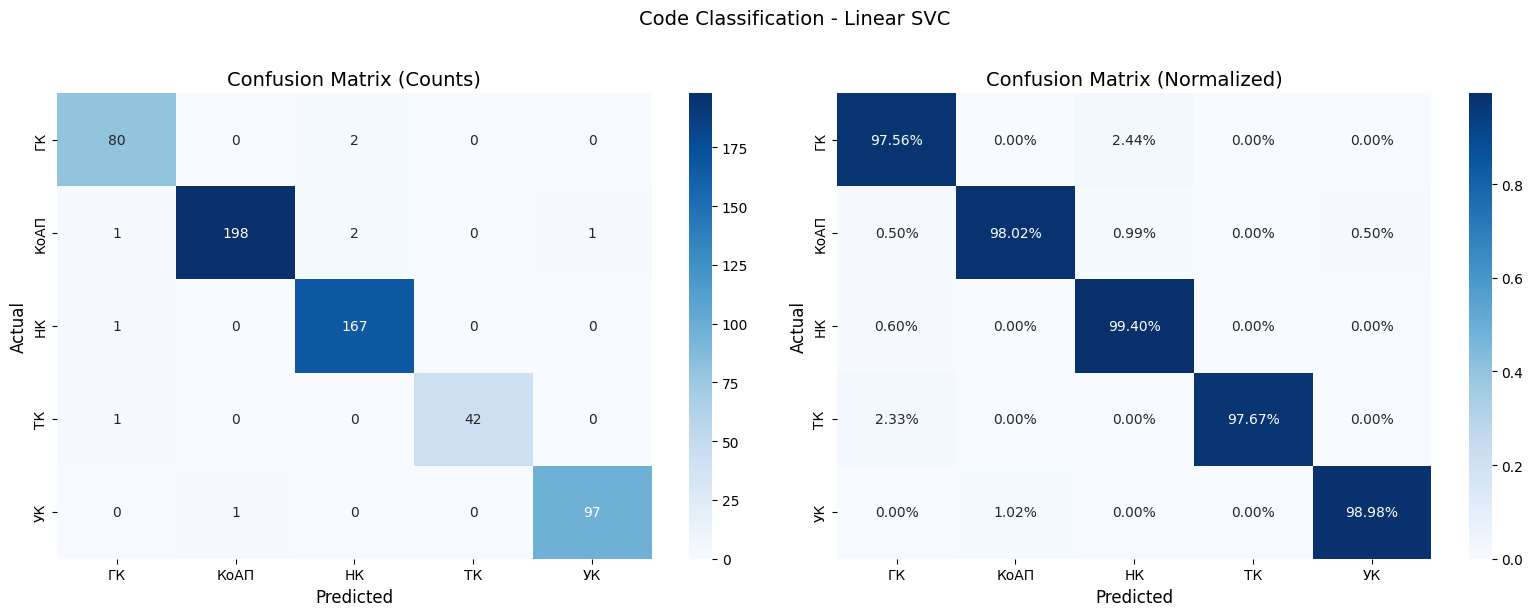


Per-Class Classification Report:
              precision    recall  f1-score   support

          ГК       0.96      0.98      0.97        82
        КоАП       0.99      0.98      0.99       202
          НК       0.98      0.99      0.99       168
          ТК       1.00      0.98      0.99        43
          УК       0.99      0.99      0.99        98

    accuracy                           0.98       593
   macro avg       0.99      0.98      0.98       593
weighted avg       0.98      0.98      0.98       593



In [102]:
# Train best model (LinearSVC - best on test set)
best_clf = LinearSVC(max_iter=2000, random_state=42)
best_clf.fit(X_train_tfidf, y_train)
y_pred_best = best_clf.predict(X_test_tfidf)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)

plt.suptitle('Code Classification - Linear SVC', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_code_classification.png", dpi=150, bbox_inches='tight')
plt.show()

# Per-class metrics
print("\nPer-Class Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

### 4.6 Most Informative Features

In [103]:
# Extract most informative features per class
feature_names = best_vectorizer.get_feature_names_out()

# Create mapping from label encoder classes to full names
CODE_NAMES = {
    "ГК": "Civil Code",
    "КоАП": "Administrative Code", 
    "НК": "Tax Code",
    "ТК": "Labor Code",
    "УК": "Criminal Code"
}

print("Most Informative Features per Legal Code:")
print("="*70)

top_features = {}

for i, class_name in enumerate(le.classes_):
    # Get coefficients for this class
    coef = best_clf.coef_[i]
    top_indices = coef.argsort()[-15:][::-1]  # Top 15 positive
    top_words = [(feature_names[idx], coef[idx]) for idx in top_indices]
    top_features[class_name] = top_words
    
    print(f"\n{class_name} ({CODE_NAMES[class_name]}):")
    for word, weight in top_words[:10]:
        print(f"  {word}: {weight:.4f}")

Most Informative Features per Legal Code:

ГК (Civil Code):
  законодательный: 1.4374
  законодательный акт: 1.4096
  гражданин: 1.2564
  сделка: 1.2564
  собственник: 1.1957
  обязательство: 1.1891
  товарищество: 1.1399
  должник: 1.0761
  законодательство: 1.0705
  вещь: 1.0125

КоАП (Administrative Code):
  административный: 2.8249
  влечь штраф: 2.2041
  влечь: 2.0833
  административный правонарушение: 1.5951
  штраф: 1.4469
  постановление: 1.1939
  дело: 1.1077
  правонарушение: 1.0778
  судья: 1.0149
  субъект: 1.0122

НК (Tax Code):
  налоговый: 2.6774
  ставка: 1.3161
  налогообложение: 1.2839
  налоговый орган: 1.2766
  доход: 1.1628
  налог: 1.1597
  налогоплательщик: 1.0380
  являться: 1.0363
  реализация: 0.9257
  услуга: 0.9189

ТК (Labor Code):
  трудовой: 2.1969
  труд: 2.1568
  работник: 1.8983
  работодатель: 1.4868
  трудовой договор: 0.9038
  рабочий: 0.8844
  работа: 0.8688
  профессиональный: 0.8612
  закон республика: 0.8315
  коллективный: 0.7880

УК (Criminal 

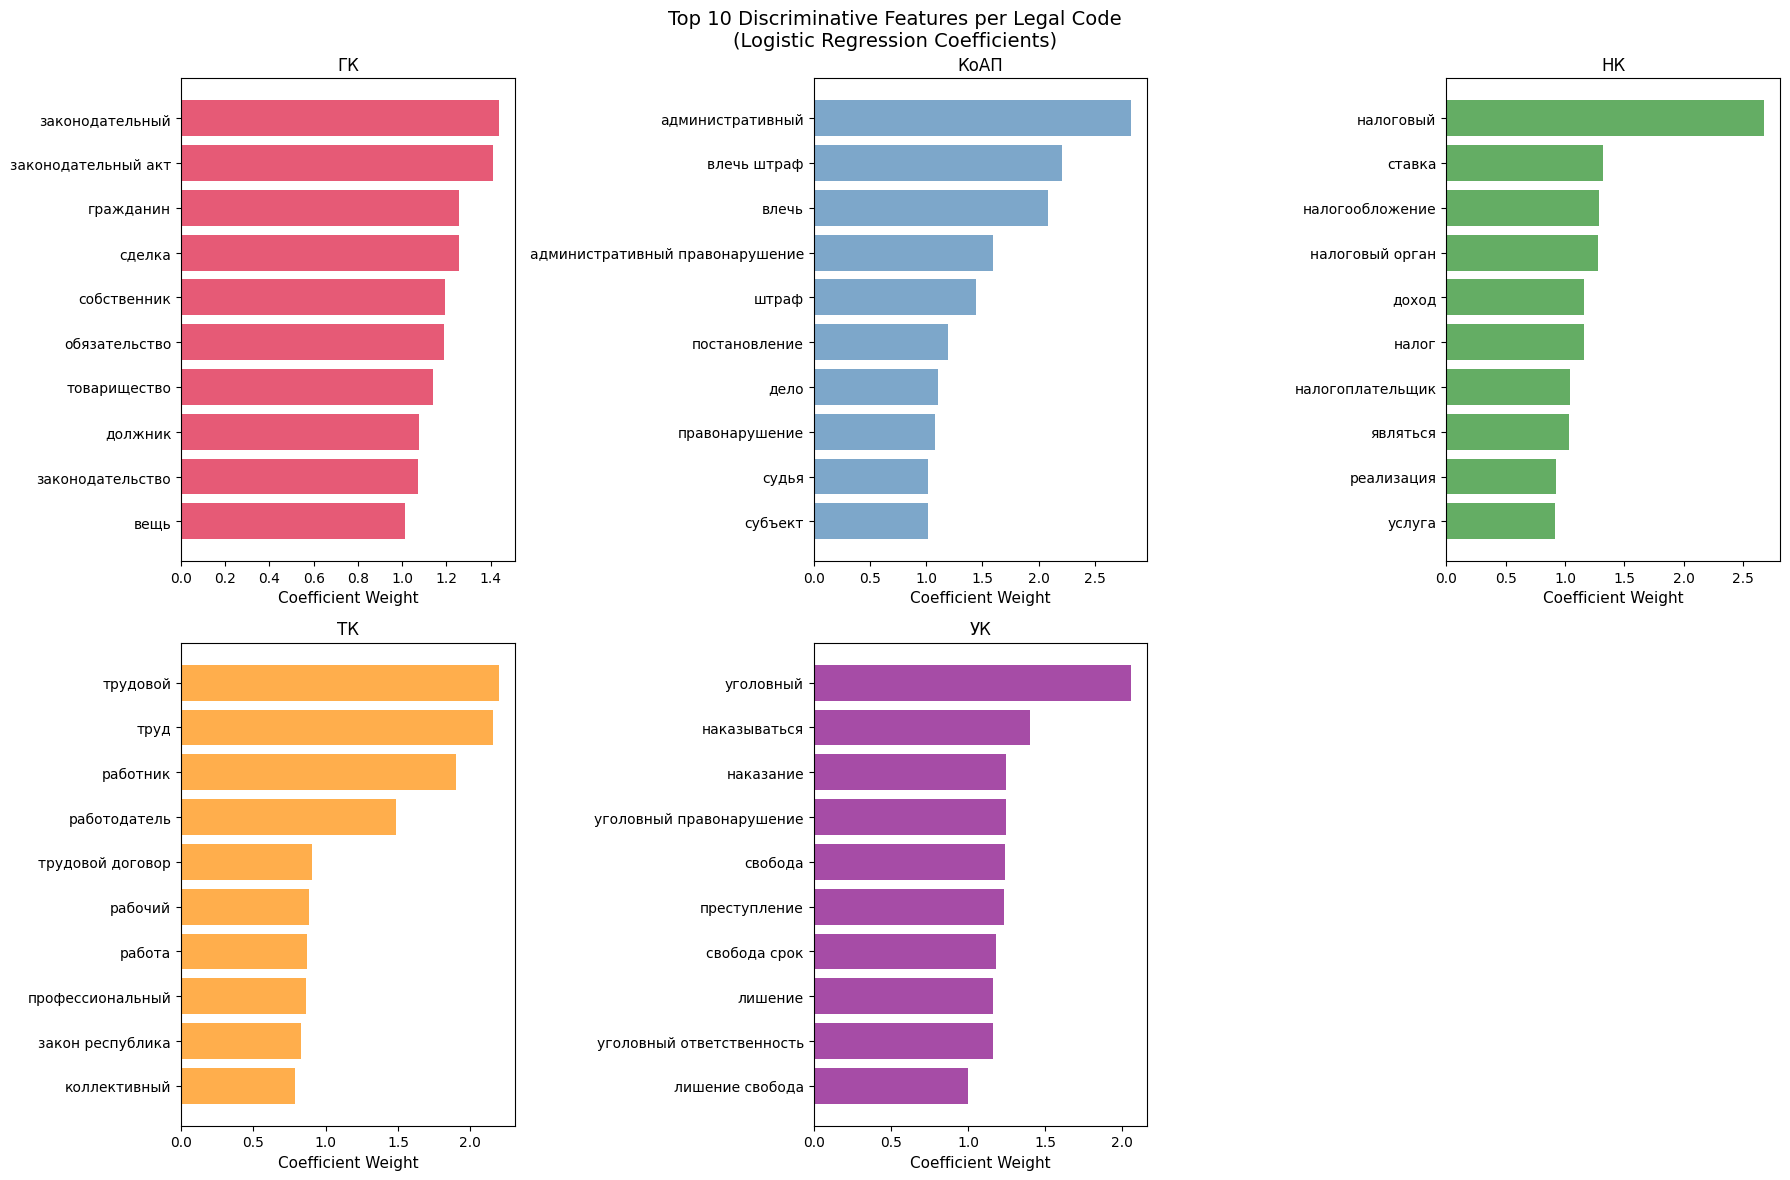

In [104]:
# Visualize top features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['crimson', 'steelblue', 'forestgreen', 'darkorange', 'purple']

for idx, (class_name, features) in enumerate(top_features.items()):
    ax = axes[idx]
    words, weights = zip(*features[:10])
    
    y_pos = range(len(words))
    ax.barh(y_pos, weights, color=colors[idx], alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient Weight', fontsize=11)
    ax.set_title(f'{class_name}', fontsize=12)

axes[-1].axis('off')

plt.suptitle('Top 10 Discriminative Features per Legal Code\n(Logistic Regression Coefficients)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_features_per_code.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.7. Model Comparison Visualization

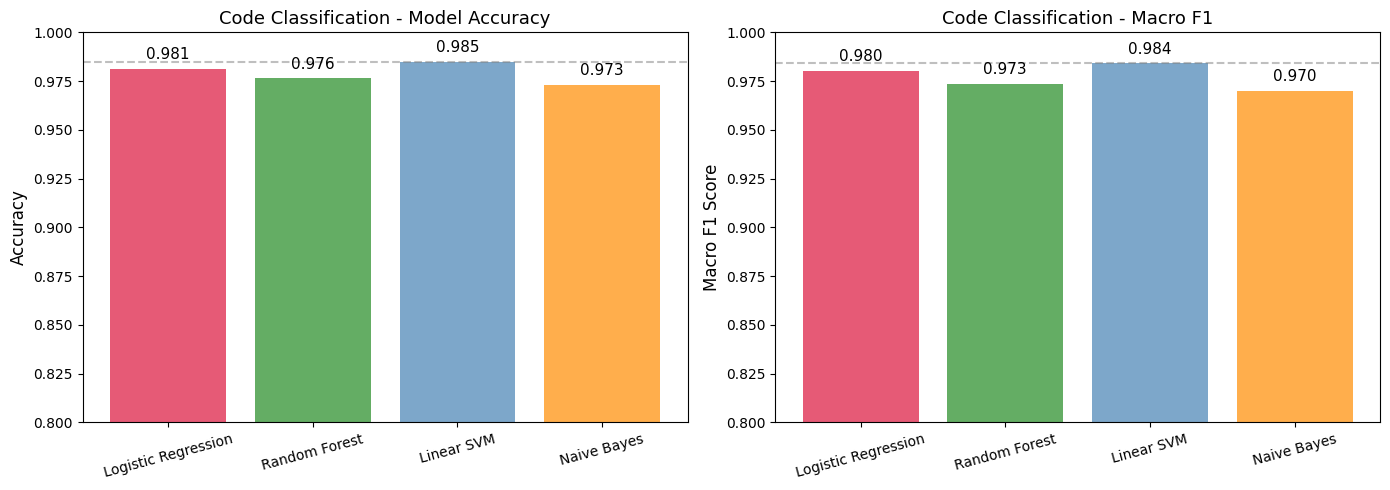

In [105]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
models = model_df['Model']
accuracies = model_df['Accuracy']
colors = ['crimson', 'forestgreen', 'steelblue', 'darkorange']
best_acc = accuracies.max()

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7)
ax1.set_ylim(0.8, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Code Classification - Model Accuracy', fontsize=13)
ax1.tick_params(axis='x', rotation=15)
ax1.axhline(y=best_acc, color='gray', linestyle='--', alpha=0.5)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', fontsize=11)

# F1 comparison
ax2 = axes[1]
f1_scores = model_df['Macro F1']
best_f1 = f1_scores.max()

bars = ax2.bar(models, f1_scores, color=colors, alpha=0.7)
ax2.set_ylim(0.8, 1.0)
ax2.set_ylabel('Macro F1 Score', fontsize=12)
ax2.set_title('Code Classification - Macro F1', fontsize=13)
ax2.tick_params(axis='x', rotation=15)
ax2.axhline(y=best_f1, color='gray', linestyle='--', alpha=0.5)

for bar, f1 in zip(bars, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{f1:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Penalty Type Classification

Classify articles by their primary penalty type (Criminal & Administrative codes only).

In [106]:
# Load penalty data from notebook 03
penalties_path = Path("../output/03/all_penalties.csv")

if penalties_path.exists():
    penalties_df = pd.read_csv(penalties_path)
    print(f"Loaded {len(penalties_df)} penalty records")
    print(f"\nPenalty types:")
    print(penalties_df['penalty_type'].value_counts())
else:
    print("Penalty data not found. Run notebook 03 first.")
    penalties_df = None

Loaded 4524 penalty records

Penalty types:
penalty_type
fine_mrp                   1296
imprisonment_years          894
fine_mrp_subject            553
correctional_work           479
restriction_freedom         419
community_service_hours     402
arrest_days                 219
warning                     120
confiscation                 42
suspension                   40
life_imprisonment            28
license_revocation           20
deportation                  12
Name: count, dtype: int64


In [107]:
penalties_df.head(3)

,code_type,article_id,article_title,section,chapter,part,num_alternatives,penalty_type,min_value,max_value,has_value,severity_score
0,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,NaN,1,1,imprisonment_years,NaN,NaN,False,0.0
1,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,NaN,15,2,imprisonment_years,NaN,NaN,False,0.0
2,Criminal,z432,Статья 99. Убийство,РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,NaN,15,2,confiscation,NaN,NaN,False,0.0


In [108]:
if penalties_df is not None:
    # Map code_type to code_short for proper joining
    code_type_map = {
        "Criminal": "УК",
        "Administrative": "КоАП"
    }
    penalties_df['code_short'] = penalties_df['code_type'].map(code_type_map)
    
    # Get primary penalty type per article AND code (important: article_id is not unique across codes!)
    primary_penalty = penalties_df.groupby(['article_id', 'code_short'])['penalty_type'].agg(
        lambda x: x.value_counts().index[0]
    ).reset_index()
    primary_penalty.columns = ['article_id', 'code_short', 'primary_penalty']
    
    print(f"Primary penalties extracted: {len(primary_penalty)}")
    print(f"  - Criminal (УК): {(primary_penalty['code_short'] == 'УК').sum()}")
    print(f"  - Administrative (КоАП): {(primary_penalty['code_short'] == 'КоАП').sum()}")
    
    # Merge with article texts - now matching on BOTH article_id AND code_short
    penalty_articles = df[df['code_short'].isin(['УК', 'КоАП'])].copy()
    penalty_articles = penalty_articles.merge(primary_penalty, on=['article_id', 'code_short'], how='inner')
    
    print(f"\nArticles with penalty labels: {len(penalty_articles)}")
    print(f"\nPrimary penalty distribution:")
    print(penalty_articles['primary_penalty'].value_counts())
    
    # Verify: check that fine_mrp_subject only appears in КоАП
    print(f"\nVerification - fine_mrp_subject by code:")
    if 'fine_mrp_subject' in penalty_articles['primary_penalty'].values:
        print(penalty_articles[penalty_articles['primary_penalty'] == 'fine_mrp_subject']['code_short'].value_counts())
    
    # Filter to top penalty types (at least 50 samples)
    penalty_counts = penalty_articles['primary_penalty'].value_counts()
    valid_penalties = penalty_counts[penalty_counts >= 50].index.tolist()
    
    penalty_articles_filtered = penalty_articles[
        penalty_articles['primary_penalty'].isin(valid_penalties)
    ].copy()
    
    print(f"\nFiltered to {len(valid_penalties)} penalty types with 50+ samples:")
    print(penalty_articles_filtered['primary_penalty'].value_counts())

Primary penalties extracted: 974
  - Criminal (УК): 386
  - Administrative (КоАП): 588

Articles with penalty labels: 976

Primary penalty distribution:
primary_penalty
fine_mrp                   436
imprisonment_years         230
fine_mrp_subject           217
warning                     45
restriction_freedom         14
suspension                  11
confiscation                 9
arrest_days                  6
deportation                  3
community_service_hours      2
license_revocation           2
correctional_work            1
Name: count, dtype: int64

Verification - fine_mrp_subject by code:
code_short
КоАП    217
Name: count, dtype: int64

Filtered to 3 penalty types with 50+ samples:
primary_penalty
fine_mrp              436
imprisonment_years    230
fine_mrp_subject      217
Name: count, dtype: int64


In [109]:
penalty_articles_filtered.shape

(883, 10)

In [110]:
penalty_articles_filtered.head(3)

,code_key,code_short,code_name,article_id,article_title,text,section,chapter,text_processed,primary_penalty
0,criminal,УК,Criminal Code,z206,Статья 51. Выдворение за пределы Республики Ка...,1. Выдворение за пределы Республики Казахстан ...,РАЗДЕЛ 3. НАКАЗАНИЕ,None,выдворение предел республика казахстан иностра...,fine_mrp
1,criminal,УК,Criminal Code,z432,Статья 99. Убийство,"1. Убийство, то есть противоправное умышленное...",РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,убийство противоправный умышленный причинение ...,imprisonment_years
3,criminal,УК,Criminal Code,z435,"Статья 101. Убийство, совершенное в состоянии ...","1. Убийство, совершенное в состоянии внезапно ...",РАЗДЕЛ 7. ПРИНУДИТЕЛЬНЫЕ МЕРЫ МЕДИЦИНСКОГО ХАР...,None,убийство совершить состояние внезапно возникну...,imprisonment_years


In [111]:
penalties_df[penalties_df['article_id'] == 'z282']

,code_type,article_id,article_title,section,chapter,part,num_alternatives,penalty_type,min_value,max_value,has_value,severity_score,code_short
2904,Administrative,z282,Статья 84. Нарушение законодательства Республи...,Раздел 2. АДМИНИСТРАТИВНОЕ ПРАВОНАРУШЕНИЕ И АД...,Глава 9. АДМИНИСТРАТИВНАЯ ОТВЕТСТВЕННОСТЬ НЕСО...,2,1,fine_mrp_subject,20.0,20.0,True,1.0,КоАП
2905,Administrative,z282,Статья 84. Нарушение законодательства Республи...,Раздел 2. АДМИНИСТРАТИВНОЕ ПРАВОНАРУШЕНИЕ И АД...,Глава 9. АДМИНИСТРАТИВНАЯ ОТВЕТСТВЕННОСТЬ НЕСО...,2,1,fine_mrp_subject,30.0,30.0,True,1.0,КоАП


In [112]:
penalty_articles_filtered[penalty_articles_filtered['primary_penalty'] == 'fine_mrp_subject'].iloc[0]

code_key                                              administrative
code_short                                                      КоАП
code_name                                        Administrative Code
article_id                                                      z264
article_title      Статья 79. Нарушение законодательства Республи...
text               1. Незаконные сбор и (или) обработка персональ...
section            Раздел 2. АДМИНИСТРАТИВНОЕ ПРАВОНАРУШЕНИЕ И АД...
chapter            Глава 9. АДМИНИСТРАТИВНАЯ ОТВЕТСТВЕННОСТЬ НЕСО...
text_processed     незаконный сбор обработка персональный деяние ...
primary_penalty                                     fine_mrp_subject
Name: 394, dtype: object

In [115]:
if penalties_df is not None and len(penalty_articles_filtered) > 100:
    # Prepare data for penalty classification
    X_penalty = penalty_articles_filtered['text_processed']
    y_penalty = penalty_articles_filtered['primary_penalty']
    
    # Encode labels
    le_penalty = LabelEncoder()
    y_penalty_encoded = le_penalty.fit_transform(y_penalty)
    
    # Train-test split
    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
        X_penalty, y_penalty_encoded, test_size=0.2, random_state=42, stratify=y_penalty_encoded
    )
    
    # Vectorize
    vec_penalty = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
    X_train_p_vec = vec_penalty.fit_transform(X_train_p)
    X_test_p_vec = vec_penalty.transform(X_test_p)
    
    # Train classifier
    clf_penalty = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    clf_penalty.fit(X_train_p_vec, y_train_p)
    
    # Evaluate
    y_pred_p = clf_penalty.predict(X_test_p_vec)
    
    print("Penalty Type Classification Results:")
    print("="*60)
    print(f"Accuracy: {accuracy_score(y_test_p, y_pred_p):.4f}")
    print(f"Macro F1: {f1_score(y_test_p, y_pred_p, average='macro'):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_p, y_pred_p, target_names=le_penalty.classes_))
else:
    print("Insufficient data for penalty classification.")

Penalty Type Classification Results:
Accuracy: 0.8870
Macro F1: 0.8866

Classification Report:
                    precision    recall  f1-score   support

          fine_mrp       0.87      0.91      0.89        87
  fine_mrp_subject       0.93      0.84      0.88        44
imprisonment_years       0.89      0.89      0.89        46

          accuracy                           0.89       177
         macro avg       0.89      0.88      0.89       177
      weighted avg       0.89      0.89      0.89       177



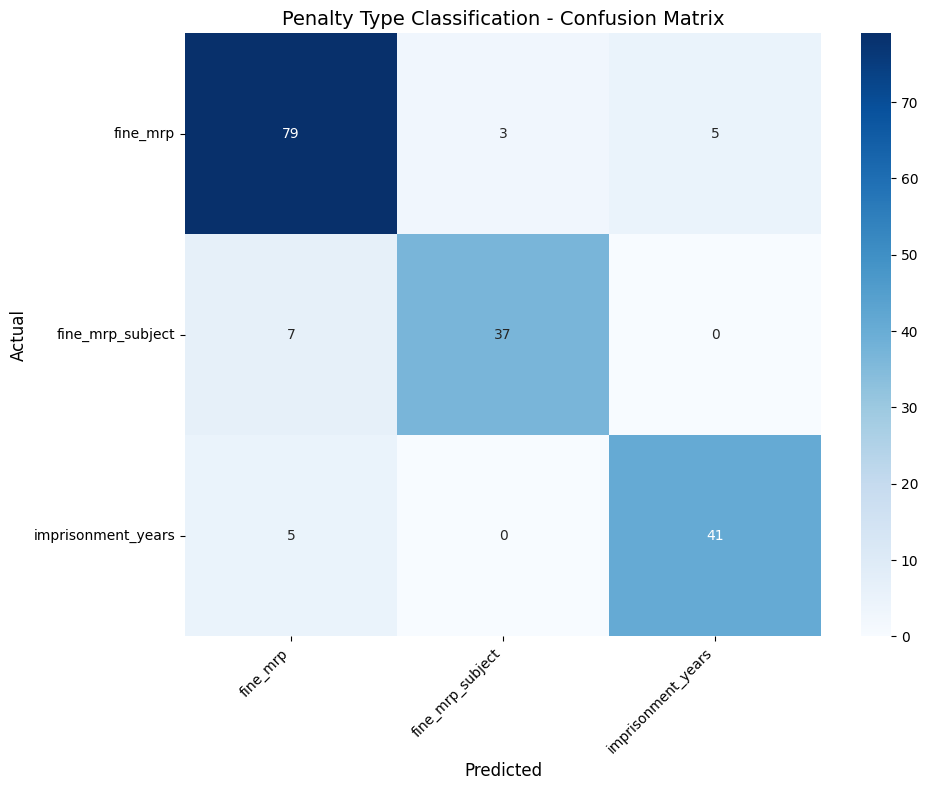

In [116]:
# Confusion matrix for penalty classification
if penalties_df is not None and len(penalty_articles_filtered) > 100:
    cm_penalty = confusion_matrix(y_test_p, y_pred_p)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_penalty, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_penalty.classes_, yticklabels=le_penalty.classes_)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Penalty Type Classification - Confusion Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confusion_matrix_penalty_classification.png", dpi=150, bbox_inches='tight')
    plt.show()

In [117]:
# Compare multiple models for penalty classification
penalty_classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Naive Bayes": MultinomialNB(),
}

penalty_model_results = []

print("Penalty Classification - Model Comparison:")
print("="*60)

for clf_name, clf in penalty_classifiers.items():
    clf.fit(X_train_p_vec, y_train_p)
    y_pred_temp = clf.predict(X_test_p_vec)
    
    acc = accuracy_score(y_test_p, y_pred_temp)
    f1 = f1_score(y_test_p, y_pred_temp, average='macro')
    
    penalty_model_results.append({
        "Model": clf_name,
        "Accuracy": acc,
        "Macro F1": f1
    })
    
    print(f"{clf_name}: Accuracy={acc:.4f}, Macro F1={f1:.4f}")

penalty_model_df = pd.DataFrame(penalty_model_results)

Penalty Classification - Model Comparison:
Logistic Regression: Accuracy=0.8870, Macro F1=0.8866
Random Forest: Accuracy=0.9492, Macro F1=0.9495
Linear SVM: Accuracy=0.9209, Macro F1=0.9215
Naive Bayes: Accuracy=0.8531, Macro F1=0.8561


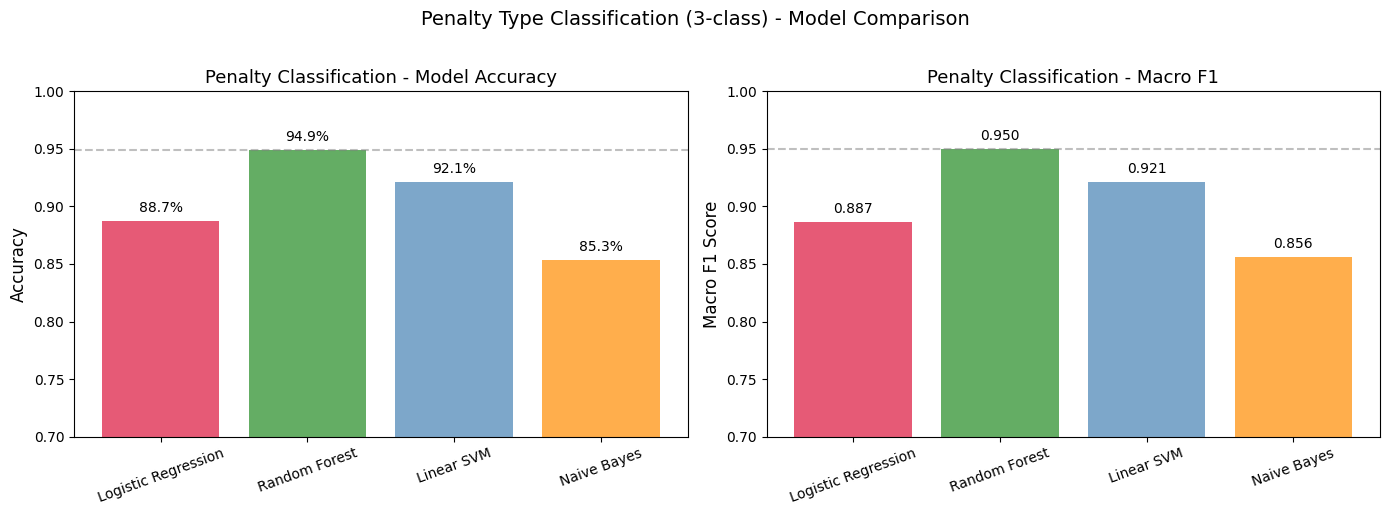


Best model: Random Forest


In [118]:
# Visualization - Penalty Classification Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['crimson', 'forestgreen', 'steelblue', 'darkorange']
best_acc = penalty_model_df['Accuracy'].max()
best_f1 = penalty_model_df['Macro F1'].max()

# Accuracy comparison
ax1 = axes[0]
bars1 = ax1.bar(penalty_model_df['Model'], penalty_model_df['Accuracy'], color=colors, alpha=0.7)
ax1.set_ylim(0.70, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Penalty Classification - Model Accuracy', fontsize=13)
ax1.tick_params(axis='x', rotation=20)
ax1.axhline(y=best_acc, color='gray', linestyle='--', alpha=0.5)
for bar, acc in zip(bars1, penalty_model_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, 
             f'{acc:.1%}', ha='center', fontsize=10)

# Macro F1 comparison
ax2 = axes[1]
bars2 = ax2.bar(penalty_model_df['Model'], penalty_model_df['Macro F1'], color=colors, alpha=0.7)
ax2.set_ylim(0.70, 1.0)
ax2.set_ylabel('Macro F1 Score', fontsize=12)
ax2.set_title('Penalty Classification - Macro F1', fontsize=13)
ax2.tick_params(axis='x', rotation=20)
ax2.axhline(y=best_f1, color='gray', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars2, penalty_model_df['Macro F1']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, 
             f'{f1:.3f}', ha='center', fontsize=10)

plt.suptitle('Penalty Type Classification (3-class) - Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_penalty.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {penalty_model_df.loc[penalty_model_df['Accuracy'].idxmax(), 'Model']}")

## 6. Error Analysis

In [119]:
# Analyze misclassified articles in code classification
test_df = df.iloc[X_test.index].copy()
test_df['predicted'] = le.inverse_transform(y_pred_best)
test_df['actual'] = le.inverse_transform(y_test)
test_df['correct'] = test_df['predicted'] == test_df['actual']

misclassified = test_df[~test_df['correct']]

print(f"Misclassified articles: {len(misclassified)} / {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)")

print("\nMost common misclassification patterns:")
confusion_pairs = misclassified.groupby(['actual', 'predicted']).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

Misclassified articles: 9 / 593 (1.5%)

Most common misclassification patterns:
actual  predicted
ГК      НК           2
КоАП    НК           2
        ГК           1
        УК           1
НК      ГК           1
ТК      ГК           1
УК      КоАП         1
dtype: int64


In [120]:
# Show example misclassifications
print("\nExample Misclassifications:")
print("="*70)

for _, row in misclassified.head(3).iterrows():
    print(f"\nActual: {row['actual']} | Predicted: {row['predicted']}")
    print(f"Title: {row['article_title'][:200]}...")
    print(f"Text: {row['text'][:300]}...")


Example Misclassifications:

Actual: ГК | Predicted: НК
Title: Статья 233. Консорциум...
Text: 1. Консорциум - это временный добровольный равноправный союз (объединение) на основе договора о совместной хозяйственной деятельности, в котором юридические лица объединяют те или иные ресурсы и координируют усилия для решения конкретных хозяйственных задач.
2. Участники консорциума сохраняют свою х...

Actual: ТК | Predicted: ГК
Title: Статья 13. Исчисление сроков, установленных настоящим Кодексом...
Text: 1. Установленный настоящим Кодексом, трудовым или коллективным договором, соглашениями срок определяется календарной датой, истечением периода времени, который исчисляется годами, месяцами, неделями или днями. Срок может определяться также указанием на событие, которое должно наступить.
2. В случаях...

Actual: КоАП | Predicted: УК
Title: Статья 37. Крайняя необходимость...
Text: 1. Не является административным правонарушением причинение вреда охраняемым настоящим Кодексом интересам в сос

## 7. Summary and Export

In [121]:
# Load version information for data sources
version_info_all = {}
for code_key, code_info in CODES.items():
    folder_path = DATA_PATH / code_info["history_folder"]
    index_path = folder_path / "versions_index.json"
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    latest = index["versions"][-1]
    version_info_all[code_key] = {
        "version_number": latest["version_number"],
        "version_date": latest["version_date"]
    }

print("="*70)
print("KEY FINDINGS - ML Classification Baseline")
print("="*70)

print("\n" + "="*70)
print("1. DATASET OVERVIEW")
print("="*70)

# Calculate class distribution dynamically
class_counts = df['code_short'].value_counts()
largest_class = class_counts.index[0]
smallest_class = class_counts.index[-1]
imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[-1]

print(f"""
   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version {version_info_all['criminal']['version_number']} ({version_info_all['criminal']['version_date']})
   • Administrative Code (КоАП): version {version_info_all['administrative']['version_number']} ({version_info_all['administrative']['version_date']})
   • Civil Code (ГК): version {version_info_all['civil']['version_number']} ({version_info_all['civil']['version_date']})
   • Labor Code (ТК): version {version_info_all['labor']['version_number']} ({version_info_all['labor']['version_date']})
   • Tax Code (НК): version {version_info_all['tax']['version_number']} ({version_info_all['tax']['version_date']})
   
   CORPUS COMPOSITION:
   ─────────────────────────────────────────────────────────────────────
   Total articles:          {len(df):,}
   Training set:            {len(X_train):,} (80%)
   Test set:                {len(X_test):,} (20%)
   
   CLASS DISTRIBUTION:
   ─────────────────────────────────────────────────────────────────────""")
for code_short in class_counts.index:
    count = class_counts[code_short]
    pct = count / len(df) * 100
    print(f"   {code_short}: {count:,} articles ({pct:.1f}%)")

print(f"""
   
   Note: Imbalanced dataset - {largest_class} has ~{imbalance_ratio:.0f}x more articles than {smallest_class} (smallest)
""")

print("="*70)
print("2. FEATURE EXTRACTION COMPARISON")
print("="*70)
print(f"""
   VECTORIZATION METHODS TESTED:
   ─────────────────────────────────────────────────────────────────────
   Method              | Features | Accuracy | Macro F1
   ────────────────────┼──────────┼──────────┼─────────""")
for _, row in feature_df.iterrows():
    print(f"   {row['Vectorizer']:20}| {row['Features']:8} | {row['Accuracy']:.4f}   | {row['Macro F1']:.4f}")

best_vec = feature_df.loc[feature_df['Accuracy'].idxmax()]
print(f"""
   
   BEST VECTORIZER: {best_vec['Vectorizer']} (Accuracy: {best_vec['Accuracy']:.2%})
   → Bigrams capture legal phrases (e.g., "лишение свободы", "влечь штраф")
   → 5,000 features sufficient for 5-class classification
""")

print("="*70)
print("3. CODE CLASSIFICATION - MODEL COMPARISON")
print("="*70)
print(f"""
   CLASSIFIER PERFORMANCE (TF-IDF 1-2-gram, 5-class):
   ─────────────────────────────────────────────────────────────────────
   Model                | Accuracy | Macro F1 | Precision | Recall
   ─────────────────────┼──────────┼──────────┼───────────┼────────""")
for _, row in model_df.iterrows():
    print(f"   {row['Model']:20}| {row['Accuracy']:.4f}   | {row['Macro F1']:.4f}   | {row['Precision']:.4f}    | {row['Recall']:.4f}")

best_model = model_df.loc[model_df['Accuracy'].idxmax()]
model_ranking = model_df.sort_values('Accuracy', ascending=False)
print(f"""
   
   BEST MODEL (Test Set): {best_model['Model']}
   → Accuracy: {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.1f}%)
   → Macro F1: {best_model['Macro F1']:.4f}
   
   MODEL RANKING (Test Set):""")
for rank, (_, row) in enumerate(model_ranking.iterrows(), 1):
    print(f"   {rank}. {row['Model']} ({row['Accuracy']:.1%})")

print("\n" + "="*70)
print("4. CROSS-VALIDATION RESULTS")
print("="*70)
print(f"""
   5-FOLD STRATIFIED CROSS-VALIDATION:
   ─────────────────────────────────────────────────────────────────────
   Model                | CV Accuracy      | CV Macro F1
   ─────────────────────┼──────────────────┼─────────────────""")
for _, row in cv_df.iterrows():
    print(f"   {row['Model']:20}| {row['CV Accuracy (mean)']:.4f} ± {row['CV Accuracy (std)']:.4f} | {row['CV F1 (mean)']:.4f} ± {row['CV F1 (std)']:.4f}")

cv_ranking = cv_df.sort_values('CV Accuracy (mean)', ascending=False)
best_cv = cv_ranking.iloc[0]
print(f"""
   
   CV RANKING:""")
for rank, (_, row) in enumerate(cv_ranking.iterrows(), 1):
    print(f"   {rank}. {row['Model']} ({row['CV Accuracy (mean)']:.2%})")

print(f"""
   
   INTERPRETATION:
   → {best_cv['Model']} achieves best CV accuracy ({best_cv['CV Accuracy (mean)']:.2%})
   → Very low variance (±{best_cv['CV Accuracy (std)']:.2%}) indicates stable performance
   → All models achieve >{cv_df['CV Accuracy (mean)'].min():.0%} accuracy - task is highly feasible
""")

print("="*70)
print("5. ERROR ANALYSIS")
print("="*70)
print(f"""
   MISCLASSIFICATION SUMMARY ({best_model['Model']}):
   ─────────────────────────────────────────────────────────────────────
   Total misclassified:    {len(misclassified)} / {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)
   
   MOST COMMON CONFUSION PAIRS:
   ─────────────────────────────────────────────────────────────────────""")
for (actual, predicted), count in confusion_pairs.head(5).items():
    print(f"   {actual} → {predicted}: {count} case(s)")

# Find most common error
if len(confusion_pairs) > 0:
    top_error = confusion_pairs.index[0]
    top_error_count = confusion_pairs.iloc[0]
    print(f"""
   
   ANALYSIS:
   → {top_error[0]} → {top_error[1]} ({top_error_count} cases): Most common error
   → Overall error rate very low ({len(misclassified)/len(test_df)*100:.1f}%)
   → No systematic confusion between unrelated codes
""")

print("="*70)
print("6. DISCRIMINATIVE FEATURES")
print("="*70)
print(f"""
   TOP DISCRIMINATIVE TERMS PER CODE ({best_model['Model']} coefficients):
   ─────────────────────────────────────────────────────────────────────""")
for code, features in top_features.items():
    top3 = [f[0] for f in features[:3]]
    code_name = CODE_NAMES.get(code, code)
    print(f"   {code} ({code_name}): {', '.join(top3)}")

print(f"""
   
   KEY INSIGHT: Domain vocabulary is highly predictive
   → Validates findings from notebooks 04-05 (topic/n-gram analysis)
""")

print("="*70)
print("7. PENALTY TYPE CLASSIFICATION")
print("="*70)
if penalties_df is not None and len(penalty_articles_filtered) > 100:
    print(f"""
   TASK: Predict primary penalty type from article text
   ─────────────────────────────────────────────────────────────────────
   Classes:     {len(le_penalty.classes_)} types""")
    for cls in le_penalty.classes_:
        print(f"                • {cls}")
    
    print(f"""
   Dataset:     {len(penalty_articles_filtered)} articles
   Train/Test:  {len(X_train_p)} / {len(X_test_p)} articles
   
   MODEL COMPARISON (TF-IDF 1-2-gram, {len(le_penalty.classes_)}-class):
   ─────────────────────────────────────────────────────────────────────
   Model                | Accuracy | Macro F1
   ─────────────────────┼──────────┼──────────""")
    for _, row in penalty_model_df.iterrows():
        print(f"   {row['Model']:20}| {row['Accuracy']:.4f}   | {row['Macro F1']:.4f}")
    
    best_penalty_model = penalty_model_df.loc[penalty_model_df['Accuracy'].idxmax()]
    penalty_ranking = penalty_model_df.sort_values('Accuracy', ascending=False)
    print(f"""
   
   BEST MODEL: {best_penalty_model['Model']}
   → Accuracy: {best_penalty_model['Accuracy']:.4f} ({best_penalty_model['Accuracy']*100:.1f}%)
   → Macro F1: {best_penalty_model['Macro F1']:.4f}
   
   MODEL RANKING:""")
    for rank, (_, row) in enumerate(penalty_ranking.iterrows(), 1):
        print(f"   {rank}. {row['Model']} ({row['Accuracy']:.1%})")
    
    print(f"""
   
   ANALYSIS:
   → High accuracy ({best_penalty_model['Accuracy']:.1%}) demonstrates penalty type is predictable
   → All three classes well-separated
""")
else:
    print("   Penalty classification not performed (insufficient data)")

print("="*70)
print("8. KEY INSIGHTS FOR LEGAL AI/NLP")
print("="*70)

best_code_acc = model_df['Accuracy'].max()
best_penalty_acc = penalty_model_df['Accuracy'].max() if 'penalty_model_df' in dir() else 0

print(f"""
   CLASSIFICATION FEASIBILITY:
   ─────────────────────────────────────────────────────────────────────
   • Legal code classification: HIGHLY FEASIBLE ({best_code_acc:.1%} accuracy)
   • Penalty type classification: HIGHLY FEASIBLE ({best_penalty_acc:.1%} accuracy)
   • Best code model: {best_model['Model']} (test) / {best_cv['Model']} (CV)
   • Simple TF-IDF + linear classifier sufficient
   • No need for complex deep learning for these tasks
   
   PRACTICAL APPLICATIONS:
   ─────────────────────────────────────────────────────────────────────
   • Document routing in legal information systems
   • Automatic tagging of new legal provisions
   • Quality control for legal database management
   • Legal search engine query classification
   • Preliminary case categorization
   • Penalty type prediction for sentencing analysis
   
   FEATURE IMPORTANCE:
   ─────────────────────────────────────────────────────────────────────
   • Bigrams crucial (capture legal phrases like "лишение свободы")
   • Domain-specific vocabulary highly predictive
   • Validates topic modeling findings (notebook 04)
   • Validates n-gram analysis findings (notebook 05)
   
   LIMITATIONS:
   ─────────────────────────────────────────────────────────────────────
   • Class imbalance ({largest_class} {class_counts.iloc[0]/len(df)*100:.0f}% vs {smallest_class} {class_counts.iloc[-1]/len(df)*100:.0f}%)
   • Deleted/amended articles harder to classify
   • Cross-code references create some ambiguity
   • Model captures lexical, not semantic meaning
   
   FUTURE WORK:
   ─────────────────────────────────────────────────────────────────────
   • Test transformer models (ruBERT, XLM-R) for comparison
   • Multi-label classification (articles referencing multiple codes)
   • Hierarchical classification (section → chapter → code)
   • Fine-grained penalty severity prediction
   • Cross-lingual transfer to Kazakh language version
""")

print("="*70)

KEY FINDINGS - ML Classification Baseline

1. DATASET OVERVIEW

   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version 109 (16.09.2025)
   • Administrative Code (КоАП): version 205 (17.12.2025)
   • Civil Code (ГК): version 179 (20.11.2025)
   • Labor Code (ТК): version 69 (16.09.2025)
   • Tax Code (НК): version 1 (18.07.2025)

   CORPUS COMPOSITION:
   ─────────────────────────────────────────────────────────────────────
   Total articles:          2,964
   Training set:            2,371 (80%)
   Test set:                593 (20%)

   CLASS DISTRIBUTION:
   ─────────────────────────────────────────────────────────────────────
   КоАП: 1,009 articles (34.0%)
   НК: 838 articles (28.3%)
   УК: 489 articles (16.5%)
   ГК: 410 articles (13.8%)
   ТК: 218 articles (7.4%)


   Note: Imbalanced dataset - КоАП has ~5x more articles than ТК (smallest)

2. FEATURE EXTRACTION COMPARISON

   VECTORIZATION METHODS TESTED:
   ───

In [122]:
# Export results
model_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
cv_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)
feature_df.to_csv(OUTPUT_DIR / "feature_comparison.csv", index=False)

# Export penalty model comparison
if 'penalty_model_df' in dir():
    penalty_model_df.to_csv(OUTPUT_DIR / "penalty_model_comparison.csv", index=False)

# Export top features
top_features_export = []
for code, features in top_features.items():
    for word, weight in features:
        top_features_export.append({
            "code": code,
            "feature": word,
            "weight": weight
        })
pd.DataFrame(top_features_export).to_csv(OUTPUT_DIR / "top_features.csv", index=False)

# Export misclassified examples for analysis
misclassified[['article_id', 'article_title', 'actual', 'predicted', 'code_name']].to_csv(
    OUTPUT_DIR / "misclassified_articles.csv", index=False
)

print("Exported to output/06/:")
print("  - model_comparison.csv")
print("  - cross_validation_results.csv")
print("  - feature_comparison.csv")
print("  - penalty_model_comparison.csv")
print("  - top_features.csv")
print("  - misclassified_articles.csv")
print("  - confusion_matrix_code_classification.png")
print("  - confusion_matrix_penalty_classification.png")
print("  - top_features_per_code.png")
print("  - model_comparison.png")
print("  - model_comparison_penalty.png")

Exported to output/06/:
  - model_comparison.csv
  - cross_validation_results.csv
  - feature_comparison.csv
  - penalty_model_comparison.csv
  - top_features.csv
  - misclassified_articles.csv
  - confusion_matrix_code_classification.png
  - confusion_matrix_penalty_classification.png
  - top_features_per_code.png
  - model_comparison.png
  - model_comparison_penalty.png
